  Zero-Shot Results Summary
  Total clusters:     50
  Total classes:      544
  Average size:       10.9
  Singleton clusters: 21
  Large (>=10):       14


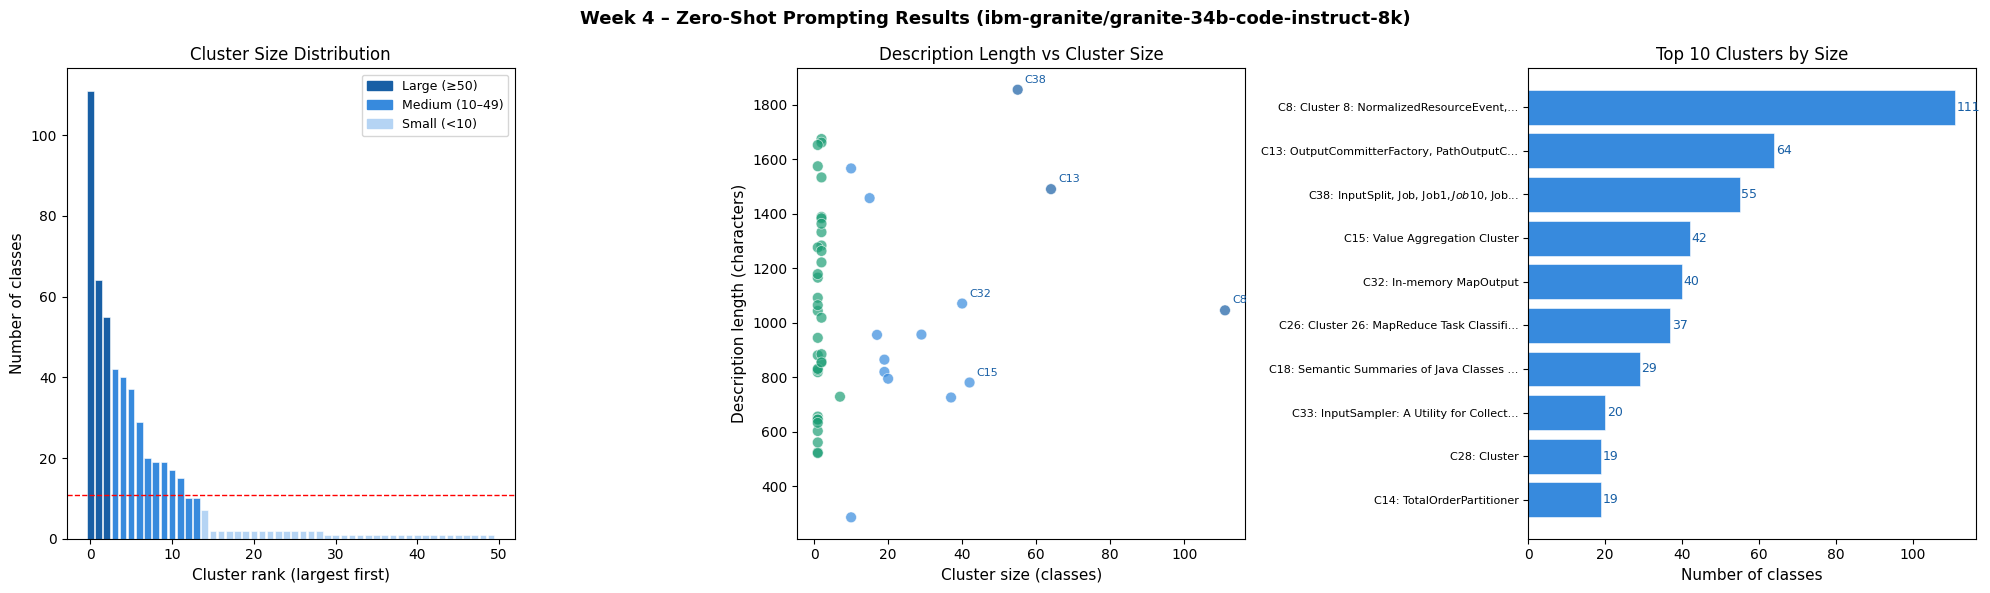

✅ Saved to /content/week4_zeroshot_analysis.png


In [3]:
# ==========================================
# Week 4 – Zero-Shot Results Visualization
# ==========================================
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter

# ── Load results ──────────────────────────
with open("/content/cluster_descriptions.json", "r") as f:
    cluster_data = json.load(f)

# ── Extract data ──────────────────────────
cluster_ids   = list(cluster_data.keys())
cluster_sizes = [cluster_data[c]["num_classes"] for c in cluster_ids]
desc_lengths  = [len(cluster_data[c]["description"]) for c in cluster_ids]

# Extract first line as title (the model outputs "1. Title\n2. Description")
def extract_title(desc):
    lines = desc.strip().split("\n")
    for line in lines:
        line = line.strip()
        if line.startswith("1."):
            return line[2:].strip().strip('"')
        if line:
            return line[:60]
    return "N/A"

titles = {c: extract_title(cluster_data[c]["description"]) for c in cluster_ids}

# ── Sort by size ──────────────────────────
sorted_pairs = sorted(zip(cluster_sizes, cluster_ids), reverse=True)
sorted_sizes = [s for s, _ in sorted_pairs]
sorted_ids   = [i for _, i in sorted_pairs]

# ── Summary stats ─────────────────────────
total_classes   = sum(cluster_sizes)
avg_size        = np.mean(cluster_sizes)
singletons      = sum(1 for s in cluster_sizes if s == 1)
large_clusters  = sum(1 for s in cluster_sizes if s >= 10)

print("=" * 50)
print("  Zero-Shot Results Summary")
print("=" * 50)
print(f"  Total clusters:     {len(cluster_ids)}")
print(f"  Total classes:      {total_classes}")
print(f"  Average size:       {avg_size:.1f}")
print(f"  Singleton clusters: {singletons}")
print(f"  Large (>=10):       {large_clusters}")
print("=" * 50)

# ── Figure with 3 subplots ────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Week 4 – Zero-Shot Prompting Results (ibm-granite/granite-34b-code-instruct-8k)",
             fontsize=13, fontweight="bold")

# ── Plot 1: Cluster size distribution ─────
colors = ["#185FA5" if s >= 50 else "#378ADD" if s >= 10 else "#B5D4F4"
          for s in sorted_sizes]
axes[0].bar(range(len(sorted_sizes)), sorted_sizes, color=colors, edgecolor="white", linewidth=0.4)
axes[0].axhline(avg_size, color="red", linestyle="--", linewidth=1,
                label=f"Mean = {avg_size:.1f}")
axes[0].set_xlabel("Cluster rank (largest first)", fontsize=11)
axes[0].set_ylabel("Number of classes", fontsize=11)
axes[0].set_title("Cluster Size Distribution", fontsize=12)
axes[0].legend(fontsize=10)

legend_patches = [
    mpatches.Patch(color="#185FA5", label="Large (≥50)"),
    mpatches.Patch(color="#378ADD", label="Medium (10–49)"),
    mpatches.Patch(color="#B5D4F4", label="Small (<10)"),
]
axes[0].legend(handles=legend_patches, fontsize=9, loc="upper right")

# ── Plot 2: Description length vs cluster size ──
scatter_colors = ["#185FA5" if s >= 50 else "#378ADD" if s >= 10 else "#1D9E75"
                  for s in cluster_sizes]
axes[1].scatter(cluster_sizes, desc_lengths, c=scatter_colors, alpha=0.7,
                s=60, edgecolors="white", linewidths=0.5)
axes[1].set_xlabel("Cluster size (classes)", fontsize=11)
axes[1].set_ylabel("Description length (characters)", fontsize=11)
axes[1].set_title("Description Length vs Cluster Size", fontsize=12)

# Annotate top 5 largest
top5 = sorted(zip(cluster_sizes, desc_lengths, cluster_ids), reverse=True)[:5]
for s, d, cid in top5:
    axes[1].annotate(f"C{cid}", (s, d), fontsize=8,
                     xytext=(5, 5), textcoords="offset points", color="#185FA5")

# ── Plot 3: Top 10 clusters by size ───────
top10_ids   = sorted_ids[:10]
top10_sizes = sorted_sizes[:10]
top10_titles = [titles[c][:35] + "..." if len(titles[c]) > 35 else titles[c]
                for c in top10_ids]

bars = axes[2].barh(range(len(top10_ids)), top10_sizes,
                    color="#378ADD", edgecolor="white", linewidth=0.4)
axes[2].set_yticks(range(len(top10_ids)))
axes[2].set_yticklabels([f"C{cid}: {t}" for cid, t in zip(top10_ids, top10_titles)],
                         fontsize=8)
axes[2].invert_yaxis()
axes[2].set_xlabel("Number of classes", fontsize=11)
axes[2].set_title("Top 10 Clusters by Size", fontsize=12)

for i, (bar, size) in enumerate(zip(bars, top10_sizes)):
    axes[2].text(size + 0.5, i, str(size), va="center", fontsize=9, color="#185FA5")

plt.tight_layout()
plt.savefig("/content/week4_zeroshot_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved to /content/week4_zeroshot_analysis.png")

In [4]:
print(f"\n{'Cluster':<10} {'Size':<8} {'Architectural Title'}")
print("-" * 80)
for size, cid in sorted_pairs:  # ← swapped here
    title = titles[cid][:60]
    print(f"C{cid:<9} {size:<8} {title}")


Cluster    Size     Architectural Title
--------------------------------------------------------------------------------
C8         111      Cluster 8: NormalizedResourceEvent, ReduceAttemptFinishedEve
C13        64       OutputCommitterFactory, PathOutputCommitter, FileOutputCommi
C38        55       InputSplit, Job, Job$1, Job$10, Job$11, Job$12, Job$2, Job$3
C15        42       Value Aggregation Cluster
C32        40       In-memory MapOutput
C26        37       Cluster 26: MapReduce Task Classification
C18        29       Semantic Summaries of Java Classes in Apache Hadoop MapReduc
C33        20       InputSampler: A Utility for Collecting Samples and Writing a
C28        19       Cluster
C14        19       TotalOrderPartitioner
C19        17       Apache Hadoop MapReduce Counters
C16        15       RandomNameCNS, SimpleNamingService, TaskCheckpointID: Random
C25        10       FileSystemCounter and QueueInfo
C12        10       Apache Hadoop MapReduce: ClientDistributedCacheMa

  Few-Shot Results Summary
  Total clusters:     50
  Total classes:      544
  Average size:       10.9
  Singleton clusters: 21
  Large (>=10):       14


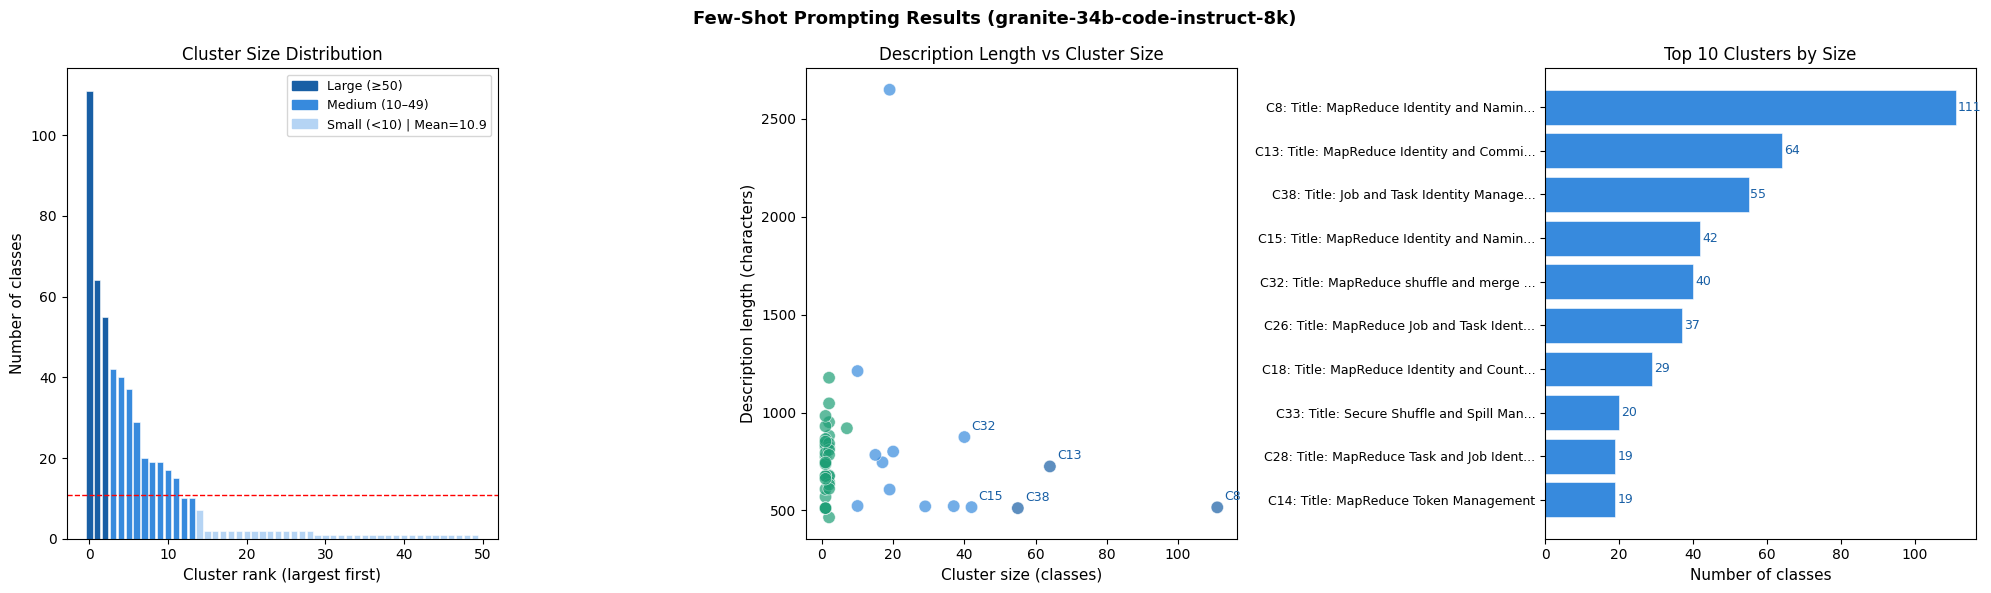

✅ Saved to /content/week4_fewshot_analysis.png

Cluster    Size     Architectural Title
--------------------------------------------------------------------------------
C8         111      Title: MapReduce Identity and Naming Scheme
C13        64       Title: MapReduce Identity and Commitment Management
C38        55       Title: Job and Task Identity Management
C15        42       Title: MapReduce Identity and Naming Scheme
C32        40       Title: MapReduce shuffle and merge management
C26        37       Title: MapReduce Job and Task Identity Management
C18        29       Title: MapReduce Identity and Counter Management
C33        20       Title: Secure Shuffle and Spill Management in MapReduce
C28        19       Title: MapReduce Task and Job Identity Management
C14        19       Title: MapReduce Token Management
C19        17       Title: MapReduce Counter Management
C16        15       Title: Cluster 16: Counters and Checkpoint Naming Services
C25        10       Title: MapR

In [5]:
# ==========================================
# Week 4 – Few-Shot Results Visualization
# ==========================================

with open("/content/fewshot/cluster_descriptions.json", "r") as f:
    fewshot_data = json.load(f)

fs_ids          = list(fewshot_data.keys())
fs_sizes        = [fewshot_data[c]["num_classes"] for c in fs_ids]
fs_desc_lengths = [len(fewshot_data[c]["description"]) for c in fs_ids]
fs_titles       = {c: extract_title(fewshot_data[c]["description"]) for c in fs_ids}

fs_sorted_pairs = sorted(zip(fs_sizes, fs_ids), reverse=True)
fs_sorted_sizes = [s for s, _ in fs_sorted_pairs]
fs_sorted_ids   = [i for _, i in fs_sorted_pairs]
fs_avg_size     = np.mean(fs_sizes)

print("=" * 50)
print("  Few-Shot Results Summary")
print("=" * 50)
print(f"  Total clusters:     {len(fs_ids)}")
print(f"  Total classes:      {sum(fs_sizes)}")
print(f"  Average size:       {fs_avg_size:.1f}")
print(f"  Singleton clusters: {sum(1 for s in fs_sizes if s == 1)}")
print(f"  Large (>=10):       {sum(1 for s in fs_sizes if s >= 10)}")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Few-Shot Prompting Results (granite-34b-code-instruct-8k)",
             fontsize=13, fontweight="bold")

# ── Plot 1: Cluster size distribution ─────
colors = ["#185FA5" if s >= 50 else "#378ADD" if s >= 10 else "#B5D4F4"
          for s in fs_sorted_sizes]
axes[0].bar(range(len(fs_sorted_sizes)), fs_sorted_sizes, color=colors,
            edgecolor="white", linewidth=0.4)
axes[0].axhline(fs_avg_size, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Cluster rank (largest first)", fontsize=11)
axes[0].set_ylabel("Number of classes", fontsize=11)
axes[0].set_title("Cluster Size Distribution", fontsize=12)
legend_patches = [
    mpatches.Patch(color="#185FA5", label="Large (≥50)"),
    mpatches.Patch(color="#378ADD", label="Medium (10–49)"),
    mpatches.Patch(color="#B5D4F4", label=f"Small (<10) | Mean={fs_avg_size:.1f}"),
]
axes[0].legend(handles=legend_patches, fontsize=9)

# ── Plot 2: Description length vs cluster size ──
scatter_colors = ["#185FA5" if s >= 50 else "#378ADD" if s >= 10 else "#1D9E75"
                  for s in fs_sizes]
axes[1].scatter(fs_sizes, fs_desc_lengths, c=scatter_colors, alpha=0.7,
                s=80, edgecolors="white", linewidths=0.5)
axes[1].set_xlabel("Cluster size (classes)", fontsize=11)
axes[1].set_ylabel("Description length (characters)", fontsize=11)
axes[1].set_title("Description Length vs Cluster Size", fontsize=12)
top5 = sorted(zip(fs_sizes, fs_desc_lengths, fs_ids), reverse=True)[:5]
for s, d, cid in top5:
    axes[1].annotate(f"C{cid}", (s, d), fontsize=9,
                     xytext=(5, 5), textcoords="offset points", color="#185FA5")

# ── Plot 3: Top 10 clusters ────────────────
fs_top10_ids    = fs_sorted_ids[:10]
fs_top10_sizes  = fs_sorted_sizes[:10]
fs_top10_titles = [fs_titles[c][:35] + "..." if len(fs_titles[c]) > 35
                   else fs_titles[c] for c in fs_top10_ids]
bars = axes[2].barh(range(len(fs_top10_ids)), fs_top10_sizes,
                    color="#378ADD", edgecolor="white", linewidth=0.4)
axes[2].set_yticks(range(len(fs_top10_ids)))
axes[2].set_yticklabels([f"C{cid}: {t}" for cid, t in
                          zip(fs_top10_ids, fs_top10_titles)], fontsize=9)
axes[2].invert_yaxis()
axes[2].set_xlabel("Number of classes", fontsize=11)
axes[2].set_title("Top 10 Clusters by Size", fontsize=12)
for i, (bar, size) in enumerate(zip(bars, fs_top10_sizes)):
    axes[2].text(size + 0.5, i, str(size), va="center", fontsize=9, color="#185FA5")

plt.tight_layout()
plt.savefig("/content/week4_fewshot_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved to /content/week4_fewshot_analysis.png")

# ── Print all titles ──────────────────────
print(f"\n{'Cluster':<10} {'Size':<8} {'Architectural Title'}")
print("-" * 80)
for size, cid in fs_sorted_pairs:
    print(f"C{cid:<9} {size:<8} {fs_titles[cid][:60]}")

  Chain-of-Thought Results Summary
  Total clusters:     50
  Total classes:      544
  Average size:       10.9
  Singleton clusters: 21
  Large (>=10):       14


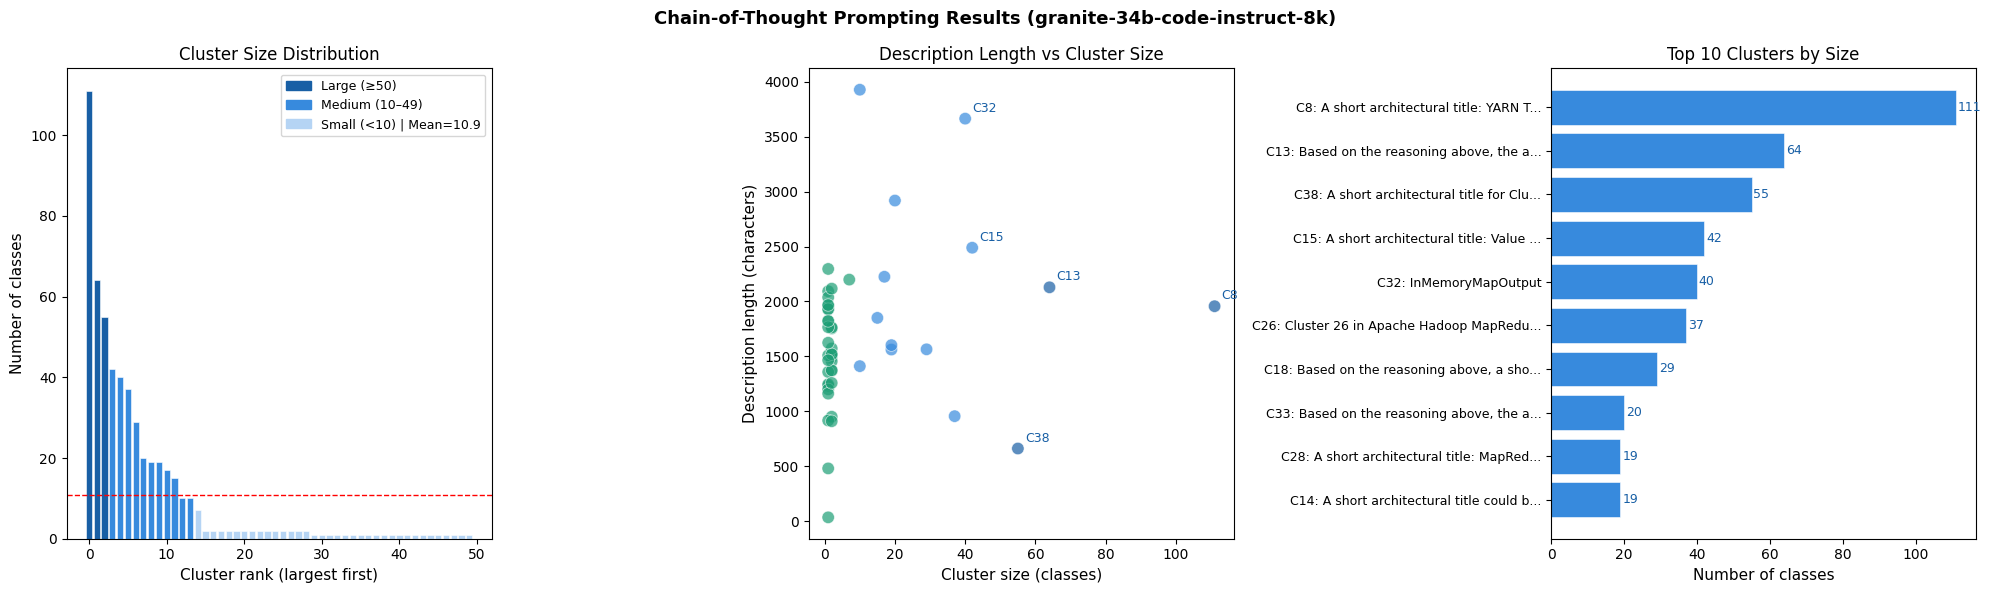

✅ Saved to /content/week4_cot_analysis.png

Cluster    Size     Architectural Title
--------------------------------------------------------------------------------
C8         111      A short architectural title: YARN Task Execution Manager
C13        64       Based on the reasoning above, the architectural title for th
C38        55       A short architectural title for Cluster 38 in Apache Hadoop 
C15        42       A short architectural title: Value Aggregation System
C32        40       InMemoryMapOutput
C26        37       Cluster 26 in Apache Hadoop MapReduce consists of classes re
C18        29       Based on the reasoning above, a short architectural title fo
C33        20       Based on the reasoning above, the architectural title for Cl
C28        19       A short architectural title: MapReduce Cluster Information A
C14        19       A short architectural title could be "Total Order Partitione
C19        17       Based on the reasoning above, the architectural title for C

In [6]:
# ==========================================
# Week 4 – Chain-of-Thought Results Visualization
# ==========================================

with open("/content/cot/cluster_descriptions.json", "r") as f:
    cot_data = json.load(f)

def extract_title_cot(desc):
    lines = desc.strip().split("\n")

    # Look for Step 5 which is where the final output is in CoT
    in_step5 = False
    for line in lines:
        line = line.strip()
        if "Step 5" in line or "step 5" in line:
            in_step5 = True
            continue
        if in_step5:
            if line.startswith("a)") or line.startswith("a."):
                return line[2:].strip().strip('"')
            if line.startswith("1."):
                return line[2:].strip().strip('"')
            if line.lower().startswith("title:"):
                return line[6:].strip().strip('"')
            if line.startswith("###"):
                return line[3:].strip()
            if line and not line.startswith("b)") and not line.startswith("2."):
                return line[:60]

    # Fallback — look for Title: anywhere
    for line in lines:
        line = line.strip()
        if line.lower().startswith("title:"):
            return line[6:].strip().strip('"')
        if line.startswith("###"):
            return line[3:].strip()

    # Last fallback
    for line in lines:
        line = line.strip()
        if line and not line.startswith("Step") and not line.startswith("//"):
            return line[:60]

    return "N/A"

cot_ids          = list(cot_data.keys())
cot_sizes        = [cot_data[c]["num_classes"] for c in cot_ids]
cot_desc_lengths = [len(cot_data[c]["description"]) for c in cot_ids]
cot_titles       = {c: extract_title_cot(cot_data[c]["description"]) for c in cot_ids}

cot_sorted_pairs = sorted(zip(cot_sizes, cot_ids), reverse=True)
cot_sorted_sizes = [s for s, _ in cot_sorted_pairs]
cot_sorted_ids   = [i for _, i in cot_sorted_pairs]
cot_avg_size     = np.mean(cot_sizes)

print("=" * 50)
print("  Chain-of-Thought Results Summary")
print("=" * 50)
print(f"  Total clusters:     {len(cot_ids)}")
print(f"  Total classes:      {sum(cot_sizes)}")
print(f"  Average size:       {cot_avg_size:.1f}")
print(f"  Singleton clusters: {sum(1 for s in cot_sizes if s == 1)}")
print(f"  Large (>=10):       {sum(1 for s in cot_sizes if s >= 10)}")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Chain-of-Thought Prompting Results (granite-34b-code-instruct-8k)",
             fontsize=13, fontweight="bold")

# ── Plot 1: Cluster size distribution ─────
colors = ["#185FA5" if s >= 50 else "#378ADD" if s >= 10 else "#B5D4F4"
          for s in cot_sorted_sizes]
axes[0].bar(range(len(cot_sorted_sizes)), cot_sorted_sizes, color=colors,
            edgecolor="white", linewidth=0.4)
axes[0].axhline(cot_avg_size, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Cluster rank (largest first)", fontsize=11)
axes[0].set_ylabel("Number of classes", fontsize=11)
axes[0].set_title("Cluster Size Distribution", fontsize=12)
legend_patches = [
    mpatches.Patch(color="#185FA5", label="Large (≥50)"),
    mpatches.Patch(color="#378ADD", label="Medium (10–49)"),
    mpatches.Patch(color="#B5D4F4", label=f"Small (<10) | Mean={cot_avg_size:.1f}"),
]
axes[0].legend(handles=legend_patches, fontsize=9)

# ── Plot 2: Description length vs cluster size ──
scatter_colors = ["#185FA5" if s >= 50 else "#378ADD" if s >= 10 else "#1D9E75"
                  for s in cot_sizes]
axes[1].scatter(cot_sizes, cot_desc_lengths, c=scatter_colors, alpha=0.7,
                s=80, edgecolors="white", linewidths=0.5)
axes[1].set_xlabel("Cluster size (classes)", fontsize=11)
axes[1].set_ylabel("Description length (characters)", fontsize=11)
axes[1].set_title("Description Length vs Cluster Size", fontsize=12)
top5 = sorted(zip(cot_sizes, cot_desc_lengths, cot_ids), reverse=True)[:5]
for s, d, cid in top5:
    axes[1].annotate(f"C{cid}", (s, d), fontsize=9,
                     xytext=(5, 5), textcoords="offset points", color="#185FA5")

# ── Plot 3: Top 10 clusters ────────────────
cot_top10_ids    = cot_sorted_ids[:10]
cot_top10_sizes  = cot_sorted_sizes[:10]
cot_top10_titles = [cot_titles[c][:35] + "..." if len(cot_titles[c]) > 35
                    else cot_titles[c] for c in cot_top10_ids]
bars = axes[2].barh(range(len(cot_top10_ids)), cot_top10_sizes,
                    color="#378ADD", edgecolor="white", linewidth=0.4)
axes[2].set_yticks(range(len(cot_top10_ids)))
axes[2].set_yticklabels([f"C{cid}: {t}" for cid, t in
                          zip(cot_top10_ids, cot_top10_titles)], fontsize=9)
axes[2].invert_yaxis()
axes[2].set_xlabel("Number of classes", fontsize=11)
axes[2].set_title("Top 10 Clusters by Size", fontsize=12)
for i, (bar, size) in enumerate(zip(bars, cot_top10_sizes)):
    axes[2].text(size + 0.5, i, str(size), va="center", fontsize=9, color="#185FA5")

plt.tight_layout()
plt.savefig("/content/week4_cot_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved to /content/week4_cot_analysis.png")

# ── Print all titles ──────────────────────
print(f"\n{'Cluster':<10} {'Size':<8} {'Architectural Title'}")
print("-" * 80)
for size, cid in cot_sorted_pairs:
    print(f"C{cid:<9} {size:<8} {cot_titles[cid][:60]}")